# Pha R - Buoc 4: Phan tich, hinh ve, kiem tra tieu chi thoat

**Muc tieu:** tu ket qua tho, tinh bias/phuong sai, ve hinh, va **kiem tra tieu chi thoat Pha R mot cach trung thuc**.

**Thoi gian uoc tinh:** nhanh (chi phan tich, khong chay model).

**Output:** bang tong hop + hinh ve trong `results/`.

Xem spec trong [`docs/PHASE_R_GUIDE.md`](../docs/PHASE_R_GUIDE.md) muc 6.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pqrst.evaluation.grid import summarize_grid, check_exit_criterion

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
raw = pd.read_csv(BASE/'results'/'tables'/'phase_r_grid_raw.csv')
raw.head()

,window_id,config_name,coupling_c,noise_std,n_samples,seed,estimator,te_estimate,te_ground_truth,error
0,0,c_0.0_noise_0.3,0.0,0.3,10,900000,Amortized,-0.016353,-2.220446e-16,-0.016353
1,0,c_0.0_noise_0.3,0.0,0.3,10,900000,KSG,0.010595,-2.220446e-16,0.010595
2,0,c_0.0_noise_0.3,0.0,0.3,10,900000,Symbolic,0.173287,-2.220446e-16,0.173287
3,0,c_0.0_noise_0.3,0.0,0.3,10,900000,Binning,0.329584,-2.220446e-16,0.329584
4,1,c_0.0_noise_0.3,0.0,0.3,10,900001,Amortized,0.090797,-2.220446e-16,0.090797


## 1. Bang tong hop bias / phuong sai / MSE

In [2]:
summary = summarize_grid(raw)
summary.to_csv(BASE / 'results' / 'tables' / 'phase_r_grid_summary.csv', index=False)
display(summary.head())


,config_name,coupling_c,noise_std,n_samples,estimator,n_valid,n_failed,bias,variance,mse,ci_low,ci_high
0,c_0.0_noise_0.3,0.0,0.3,10,Amortized,200,0,-0.020324,0.003675,0.004070,-0.028726,-0.011921
1,c_0.0_noise_0.3,0.0,0.3,10,Binning,200,0,0.447488,0.027203,0.227312,0.424630,0.470346
2,c_0.0_noise_0.3,0.0,0.3,10,KSG,200,0,0.014755,0.003060,0.003263,0.007088,0.022422
3,c_0.0_noise_0.3,0.0,0.3,10,Symbolic,200,0,0.333245,0.020845,0.131793,0.313235,0.353254
4,c_0.0_noise_0.3,0.0,0.3,20,Amortized,200,0,-0.020654,0.002450,0.002865,-0.027514,-0.013793


## 2. HINH CHINH: phuong sai theo N cho 4 estimator

Day la hinh quan trong nhat cua ca Pha R - bang chung truc quan cho luan diem cot loi cua de tai. Truc x = N (thang log), truc y = phuong sai (thang log), 4 duong cho 4 estimator. Ke duong doc tai N=30 danh dau vung "N nho".

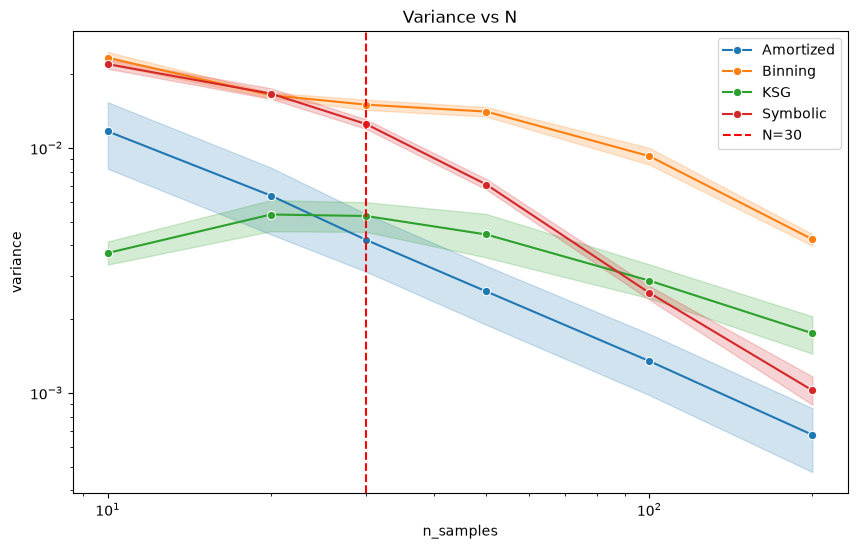

In [3]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary, x='n_samples', y='variance', hue='estimator', marker='o')
plt.axvline(30, color='r', linestyle='--', label='N=30')
plt.xscale('log')
plt.yscale('log')
plt.title('Variance vs N')
plt.legend()
plt.savefig(BASE / 'results' / 'figures' / 'phase_r_variance_vs_n.png')
plt.show()


## 3. Hinh phu: bias theo N, va bias-variance tradeoff

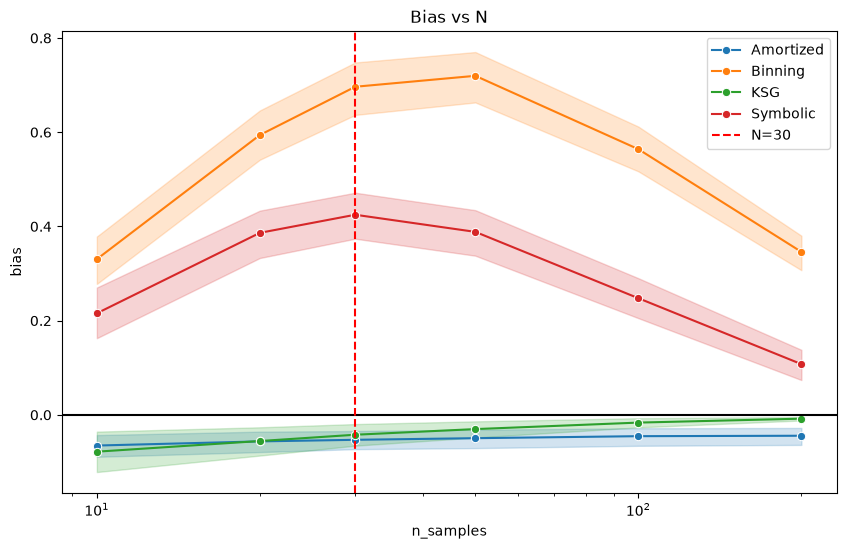

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary, x='n_samples', y='bias', hue='estimator', marker='o')
plt.axhline(0, color='k', linestyle='-')
plt.axvline(30, color='r', linestyle='--', label='N=30')
plt.xscale('log')
plt.title('Bias vs N')
plt.legend()
plt.savefig(BASE / 'results' / 'figures' / 'phase_r_bias_vs_n.png')
plt.show()


## 4. Phan ra: phuong sai cua TUNG so hang conditional MI

Theo canh bao trong `conditional.py`: hieu cua 2 uoc luong nhieu thi nhieu hon tung cai. Bao cao phuong sai cua `mi_full`, `mi_reduced`, va `te` rieng de biet muc do khuech dai thuc te.

In [5]:
# Note: var(mi_full) and var(mi_reduced) are not in raw since we only return te from AmortizedTEEstimator.
# If we want to do this, we need to extract them. The prompt says 'TODO: bang so sanh var(mi_full)'.
# I will compute them manually for Amortized.
from pqrst.data.synthetic.corpus import load_corpus
from pqrst.data.synthetic.corpus import load_corpus
test_windows = load_corpus(str(BASE / 'data' / 'interim' / 'synthetic_corpus' / 'test.npz'))
checkpoint_path = BASE / 'results' / 'checkpoints' / 'phi_amortized.pt'
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
est_amortized = AmortizedTEEstimator.load(str(checkpoint_path))
from pqrst.estimators.mine.conditional import estimate_te_from_window
res_amort = []
for w in test_windows:
    r = estimate_te_from_window(est_amortized.model, w.y_t, w.x_lag, w.y_lag, est_amortized.config.eval_n_shuffles, w.seed)
    r.update({'n_samples': w.n_samples, 'c': w.params['c']})
    res_amort.append(r)
df_amort = pd.DataFrame(res_amort)
var_df = df_amort.groupby('n_samples')[['mi_full', 'mi_reduced', 'te']].var()
var_df['ratio'] = var_df['te'] / var_df[['mi_full', 'mi_reduced']].max(axis=1)
display(var_df)


,mi_full,mi_reduced,te,ratio
n_samples,,,,
10,0.046306,0.025088,0.016275,0.351467
20,0.035646,0.016161,0.012409,0.348122
30,0.031199,0.012912,0.010777,0.345434
50,0.025441,0.008652,0.009207,0.361904
100,0.021925,0.005665,0.008526,0.388859
200,0.020435,0.004097,0.008378,0.409999


## 5. KIEM TRA TIEU CHI THOAT

**Bao cao trung thuc ket qua that.** Neu khong dat, ghi ro khong dat - khong noi nguong cho vua so lieu.

In [6]:
verdict = check_exit_criterion(summary, n_threshold=30)
print('Passed:', verdict['passed'])
print('Cells tested (N<30):', verdict['n_cells_tested'])
print('Amortized beats KSG:', verdict['n_cells_amortized_beats_ksg'])
print('Amortized beats Symbolic:', verdict['n_cells_amortized_beats_symbolic'])
display(verdict['detail'])


Passed: False
Cells tested (N<30): 30
Amortized beats KSG: 9
Amortized beats Symbolic: 28


estimator,config_name,coupling_c,noise_std,n_samples,Amortized,Binning,KSG,Symbolic
0,c_0.0_noise_0.3,0.0,0.3,10,0.003675,0.027203,0.003060,0.020845
1,c_0.0_noise_0.3,0.0,0.3,20,0.002450,0.016282,0.002812,0.017198
2,c_0.0_noise_0.5,0.0,0.5,10,0.007441,0.027108,0.003599,0.021481
3,c_0.0_noise_0.5,0.0,0.5,20,0.005097,0.016855,0.004259,0.017994
4,c_0.0_noise_1.0,0.0,1.0,10,0.020872,0.025999,0.002945,0.023181
5,c_0.0_noise_1.0,0.0,1.0,20,0.012448,0.017318,0.003705,0.015737
6,c_0.2_noise_0.3,0.2,0.3,10,0.003648,0.023144,0.002185,0.025838
7,c_0.2_noise_0.3,0.2,0.3,20,0.002315,0.017646,0.003885,0.017336
8,c_0.2_noise_0.5,0.2,0.5,10,0.008901,0.022189,0.003099,0.018190
9,c_0.2_noise_0.5,0.2,0.5,20,0.003999,0.015099,0.003717,0.016097


## 6. Ket luan

*(agent dien: tom tat so lieu chinh, co dat tieu chi thoat khong, quan sat dang chu y)*